In [1]:
import os 
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


# Load Dataset

In [2]:
data_path = os.path.join("../../Data/Telco_Customer_Churn.csv")

try:
    df = pd.read_csv(data_path, sep=';')
    print(f"Data Shape: {df.shape}")
except Exception as e:
    print(f"Error: {e}")

df.head()

Data Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
tenur_filterd = df[(df['tenure'] == 1) & (df['Churn'] == 'Yes')]
print(f'{len(tenur_filterd)}')

380


# EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Check duplicate

In [13]:
duplicate = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print(f"Jumlah data duplikat {duplicate}")
print(f"Jumlah ID duplikat {duplicate_ids}")

Jumlah data duplikat 0
Jumlah ID duplikat 0


## Data Distributions

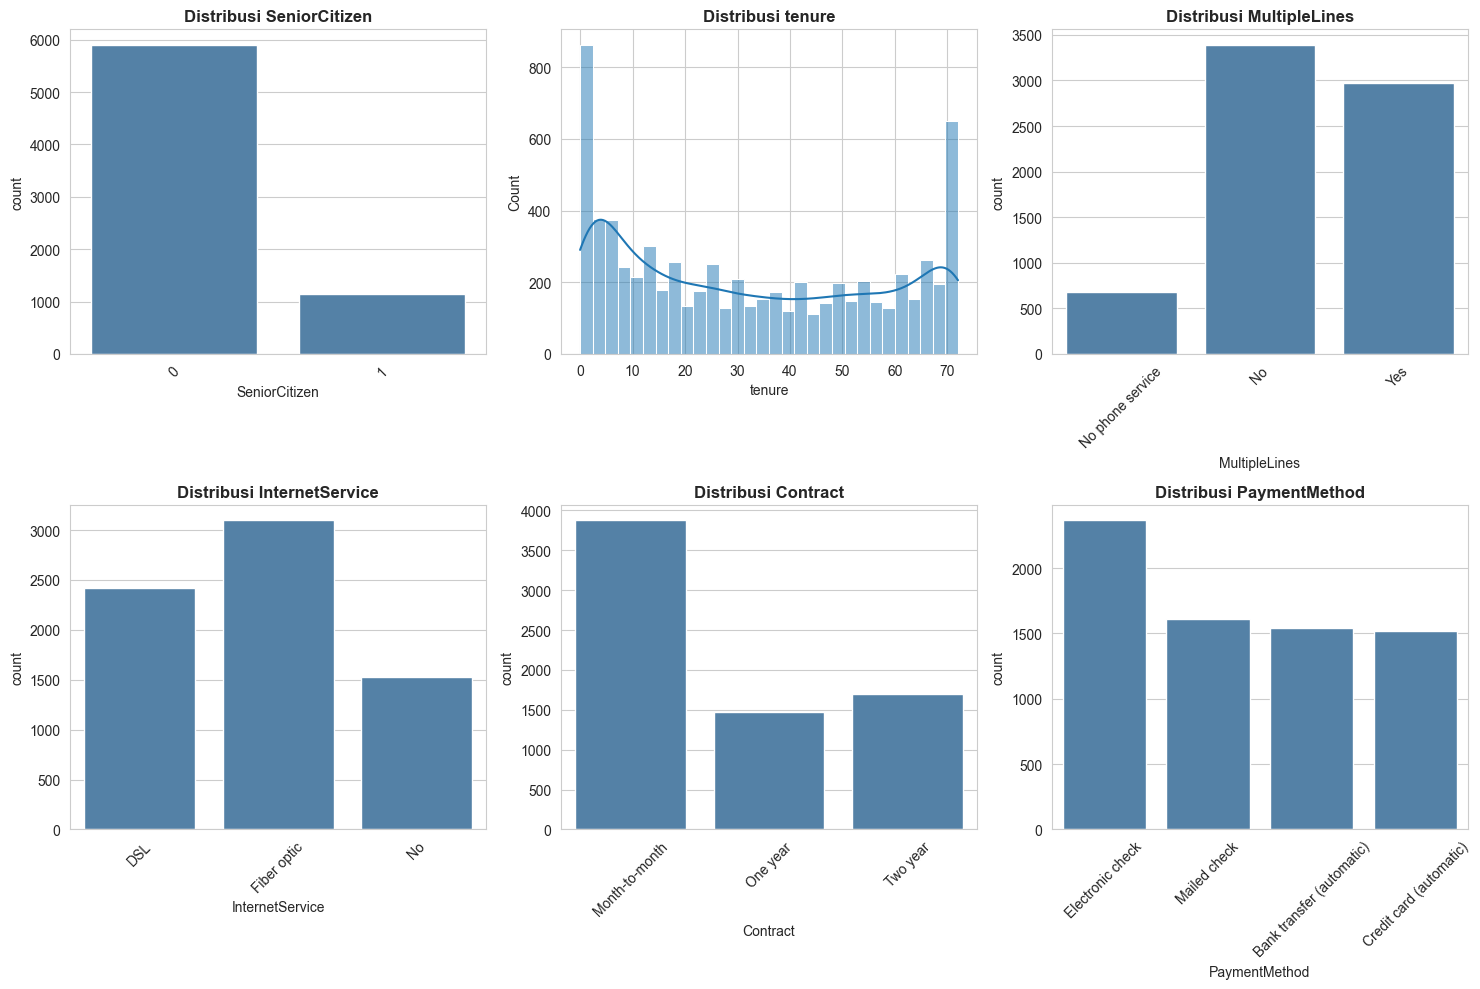

In [18]:
fig, axes = plt.subplots(2,3, figsize=(15, 10))
axes = axes.ravel()

columns = ['SeniorCitizen', 'tenure', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

for idx, col in enumerate(columns):
    if col in df.columns:
        if df[col].dtype == 'object' or df[col].nunique() <= 10:
            sns.countplot(data=df, x=col, ax=axes[idx],  color='steelblue')
            axes[idx].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
            axes[idx].tick_params(axis='x', rotation=45)
        else:
            sns.histplot(data=df, x=col, ax=axes[idx], bins=30, kde=True)
            axes[idx].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Explore Phone service and multiplelines

In [19]:
no_phone_service = df[df['MultipleLines'] == 'No phone service'][['MultipleLines', 'PhoneService']]

print('sample data')
print(no_phone_service.head(10))

print("\nDistribusi PhoneService dimana MultipleLines = 'No phone service':")
print(no_phone_service['PhoneService'].value_counts())

print("\nCrosstab (untuk melihat detail):")
print(pd.crosstab(no_phone_service['MultipleLines'], no_phone_service['PhoneService']))

sample data
        MultipleLines PhoneService
0    No phone service           No
3    No phone service           No
7    No phone service           No
20   No phone service           No
27   No phone service           No
62   No phone service           No
81   No phone service           No
89   No phone service           No
103  No phone service           No
105  No phone service           No

Distribusi PhoneService dimana MultipleLines = 'No phone service':
PhoneService
No    682
Name: count, dtype: int64

Crosstab (untuk melihat detail):
PhoneService       No
MultipleLines        
No phone service  682


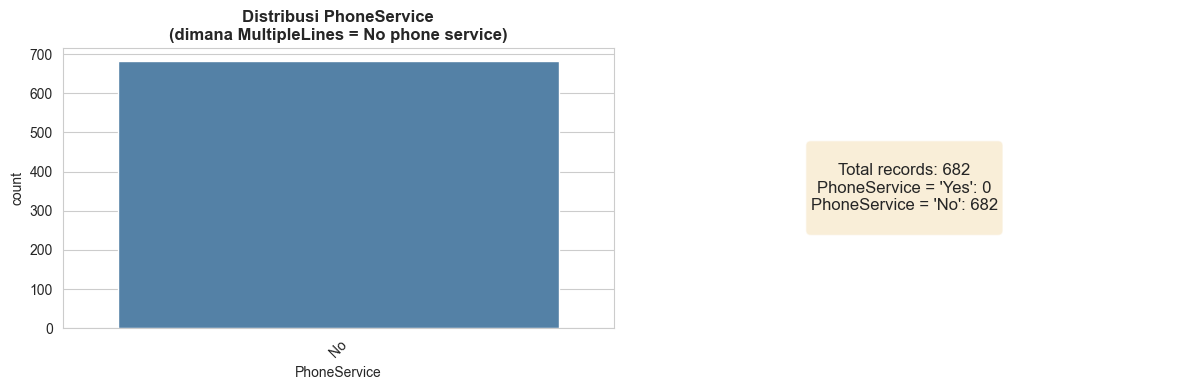

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filter data
no_phone_service = df[df['MultipleLines'] == 'No phone service']

# Bar chart: PhoneService distribution
sns.countplot(data=no_phone_service, x='PhoneService', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi PhoneService\n(dimana MultipleLines = No phone service)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Text info
info_text = f"""
Total records: {len(no_phone_service)}
PhoneService = 'Yes': {(no_phone_service['PhoneService'] == 'Yes').sum()}
PhoneService = 'No': {(no_phone_service['PhoneService'] == 'No').sum()}
"""
axes[1].text(0.5, 0.5, info_text, ha='center', va='center', fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [22]:
yes_phone_service = df[df['MultipleLines'] == 'Yes'][['MultipleLines', 'PhoneService']]

print('sample data')
print(yes_phone_service.head(10))

print("\nDistribusi PhoneService dimana MultipleLines = 'Yes':")
print(yes_phone_service['PhoneService'].value_counts())

print("\nCrosstab (untuk melihat detail):")
print(pd.crosstab(yes_phone_service['MultipleLines'], yes_phone_service['PhoneService']))

sample data
   MultipleLines PhoneService
5            Yes          Yes
6            Yes          Yes
8            Yes          Yes
12           Yes          Yes
13           Yes          Yes
15           Yes          Yes
17           Yes          Yes
23           Yes          Yes
26           Yes          Yes
28           Yes          Yes

Distribusi PhoneService dimana MultipleLines = 'Yes':
PhoneService
Yes    2971
Name: count, dtype: int64

Crosstab (untuk melihat detail):
PhoneService    Yes
MultipleLines      
Yes            2971


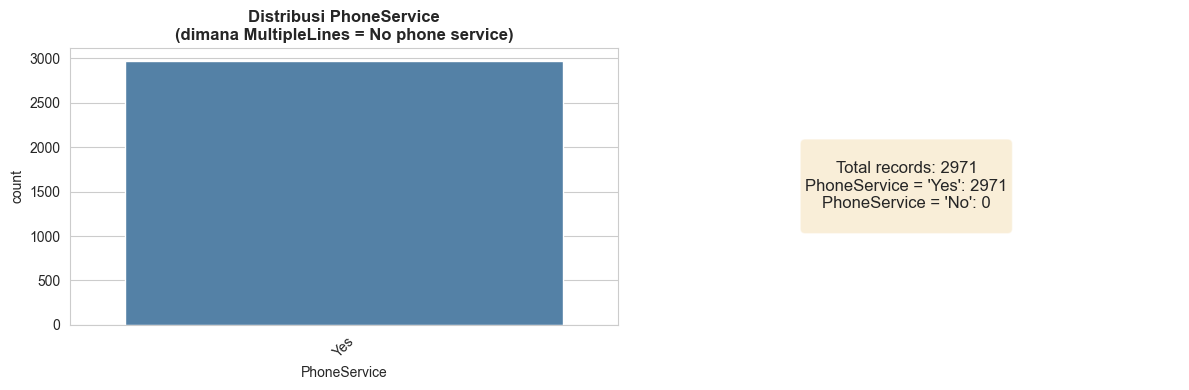

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filter data
no_phone_service = df[df['MultipleLines'] == 'Yes']

# Bar chart: PhoneService distribution
sns.countplot(data=no_phone_service, x='PhoneService', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi PhoneService\n(dimana MultipleLines = No phone service)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Text info
info_text = f"""
Total records: {len(no_phone_service)}
PhoneService = 'Yes': {(no_phone_service['PhoneService'] == 'Yes').sum()}
PhoneService = 'No': {(no_phone_service['PhoneService'] == 'No').sum()}
"""
axes[1].text(0.5, 0.5, info_text, ha='center', va='center', fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [24]:
n_phone_service = df[df['MultipleLines'] == 'No'][['MultipleLines', 'PhoneService']]

print('sample data')
print(n_phone_service.head(10))

print("\nDistribusi PhoneService dimana MultipleLines = 'Yes':")
print(n_phone_service['PhoneService'].value_counts())

print("\nCrosstab (untuk melihat detail):")
print(pd.crosstab(n_phone_service['MultipleLines'], n_phone_service['PhoneService']))

sample data
   MultipleLines PhoneService
1             No          Yes
2             No          Yes
4             No          Yes
9             No          Yes
10            No          Yes
11            No          Yes
14            No          Yes
16            No          Yes
18            No          Yes
19            No          Yes

Distribusi PhoneService dimana MultipleLines = 'Yes':
PhoneService
Yes    3390
Name: count, dtype: int64

Crosstab (untuk melihat detail):
PhoneService    Yes
MultipleLines      
No             3390


### Dependents exploration

#### Female with dependent

In [5]:
# Filter data
filtered_df = df[(df['gender'] == 'Female') & (df['Partner'] == 'No') & (df['Dependents'] == 'Yes')]

print(f"Total records: {len(filtered_df)}")
print("\n=== Churn Distribution ===")
print(filtered_df['Churn'].value_counts())

print("\n=== Churn Percentage ===")
churn_pct = filtered_df['Churn'].value_counts(normalize=True) * 100
print(churn_pct)

# Summary
print("\n=== Summary ===")
print(f"Churn: {(filtered_df['Churn'] == 'Yes').sum()} ({churn_pct.get('Yes', 0):.2f}%)")
print(f"Not Churn: {(filtered_df['Churn'] == 'No').sum()} ({churn_pct.get('No', 0):.2f}%)")

Total records: 145

=== Churn Distribution ===
Churn
No     112
Yes     33
Name: count, dtype: int64

=== Churn Percentage ===
Churn
No     77.241379
Yes    22.758621
Name: proportion, dtype: float64

=== Summary ===
Churn: 33 (22.76%)
Not Churn: 112 (77.24%)


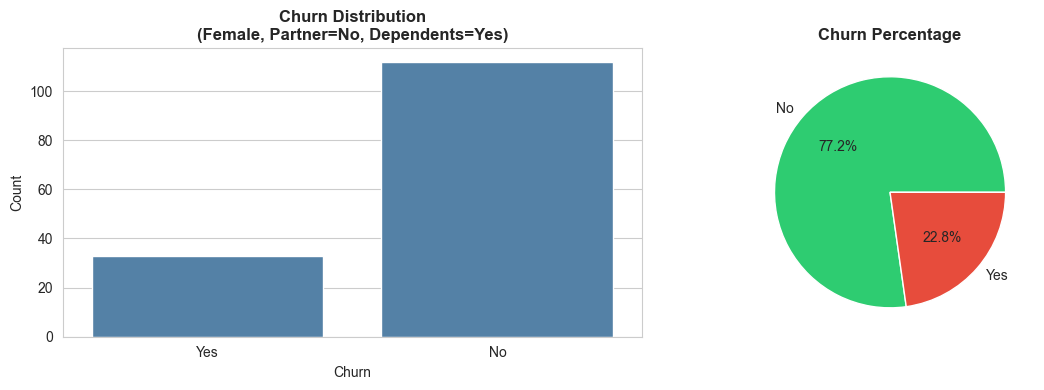


Total: 145 customers
Churn: 33 (22.76%)
Not Churn: 112 (77.24%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(data=filtered_df, x='Churn', ax=axes[0], color='steelblue')
axes[0].set_title(f'Churn Distribution\n(Female, Partner=No, Dependents=Yes)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart dengan percentage
churn_counts = filtered_df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal: {len(filtered_df)} customers")
print(f"Churn: {(filtered_df['Churn'] == 'Yes').sum()} ({(filtered_df['Churn'] == 'Yes').sum()/len(filtered_df)*100:.2f}%)")
print(f"Not Churn: {(filtered_df['Churn'] == 'No').sum()} ({(filtered_df['Churn'] == 'No').sum()/len(filtered_df)*100:.2f}%)")

##### Male with dependents

In [8]:
male_filtered_df = df[(df['gender'] == 'Male') & (df['Partner'] == 'No') & (df['Dependents'] == 'Yes')]

print(f"Total records: {len(male_filtered_df)}")
print("\n=== Churn Distribution ===")
print(male_filtered_df['Churn'].value_counts())

print("\n=== Churn Percentage ===")
churn_pct = male_filtered_df['Churn'].value_counts(normalize=True) * 100
print(churn_pct)

# Summary
print("\n=== Summary ===")
print(f"Churn: {(male_filtered_df['Churn'] == 'Yes').sum()} ({churn_pct.get('Yes', 0):.2f}%)")
print(f"Not Churn: {(male_filtered_df['Churn'] == 'No').sum()} ({churn_pct.get('No', 0):.2f}%)")

Total records: 216

=== Churn Distribution ===
Churn
No     172
Yes     44
Name: count, dtype: int64

=== Churn Percentage ===
Churn
No     79.62963
Yes    20.37037
Name: proportion, dtype: float64

=== Summary ===
Churn: 44 (20.37%)
Not Churn: 172 (79.63%)


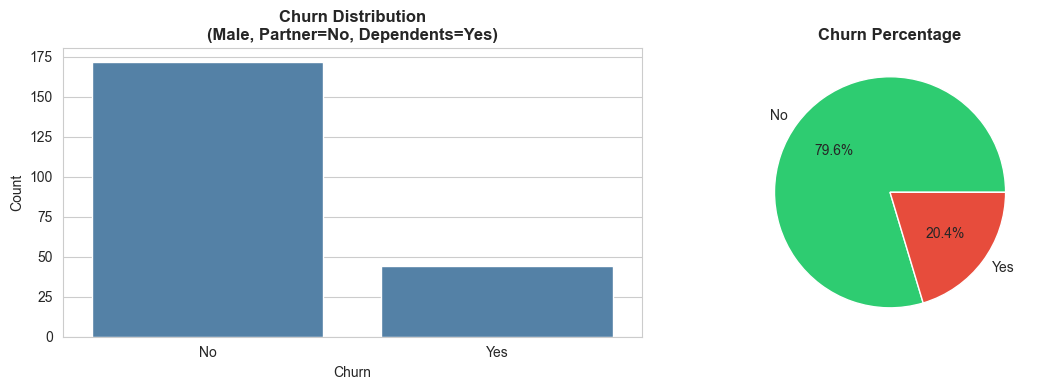


Total: 216 customers
Churn: 44 (20.37%)
Not Churn: 172 (79.63%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(data=male_filtered_df, x='Churn', ax=axes[0], color='steelblue')
axes[0].set_title(f'Churn Distribution\n(Male, Partner=No, Dependents=Yes)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart dengan percentage
churn_counts = male_filtered_df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal: {len(male_filtered_df)} customers")
print(f"Churn: {(male_filtered_df['Churn'] == 'Yes').sum()} ({(male_filtered_df['Churn'] == 'Yes').sum()/len(male_filtered_df)*100:.2f}%)")
print(f"Not Churn: {(male_filtered_df['Churn'] == 'No').sum()} ({(male_filtered_df['Churn'] == 'No').sum()/len(male_filtered_df)*100:.2f}%)")

#### grouping data

Total records: 3280
Churn
No     2157
Yes    1123
Name: count, dtype: int64

 Churn Percentage
Churn
No     65.762195
Yes    34.237805
Name: proportion, dtype: float64


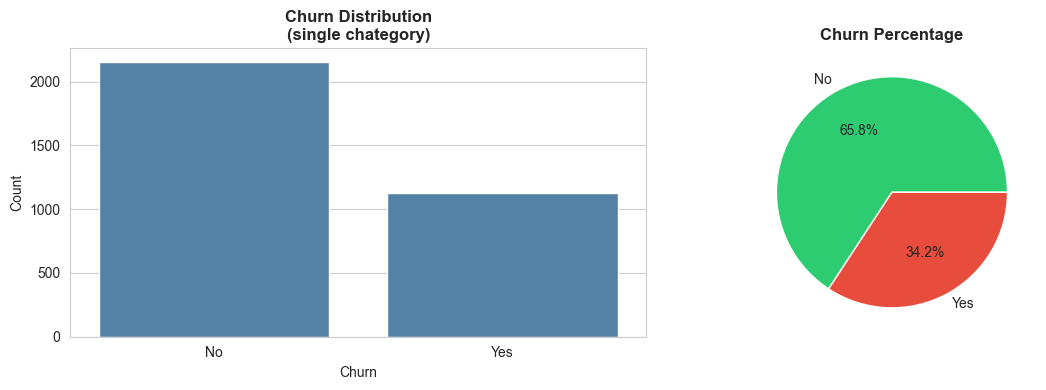


Total: 3280 customers
Churn: 1123 (34.24%)
Not Churn: 2157 (65.76%)


In [4]:
single_filtered = df[(df['Partner'] == 'No') & (df['Dependents'] == 'No')]

print(f'Total records: {len(single_filtered)}')
print(single_filtered['Churn'].value_counts())

print('\n Churn Percentage')
single_churn_pct = single_filtered['Churn'].value_counts(normalize=True)*100
print(single_churn_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(data=single_filtered, x='Churn', ax=axes[0], color='steelblue')
axes[0].set_title(f'Churn Distribution\n(single chategory)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart dengan percentage
churn_counts = single_filtered['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal: {len(single_filtered)} customers")
print(f"Churn: {(single_filtered['Churn'] == 'Yes').sum()} ({(single_filtered['Churn'] == 'Yes').sum()/len(single_filtered)*100:.2f}%)")
print(f"Not Churn: {(single_filtered['Churn'] == 'No').sum()} ({(single_filtered['Churn'] == 'No').sum()/len(single_filtered)*100:.2f}%)")

Total records: 1653
Churn
No     1233
Yes     420
Name: count, dtype: int64

 Churn Percentage
Churn
No     74.591652
Yes    25.408348
Name: proportion, dtype: float64


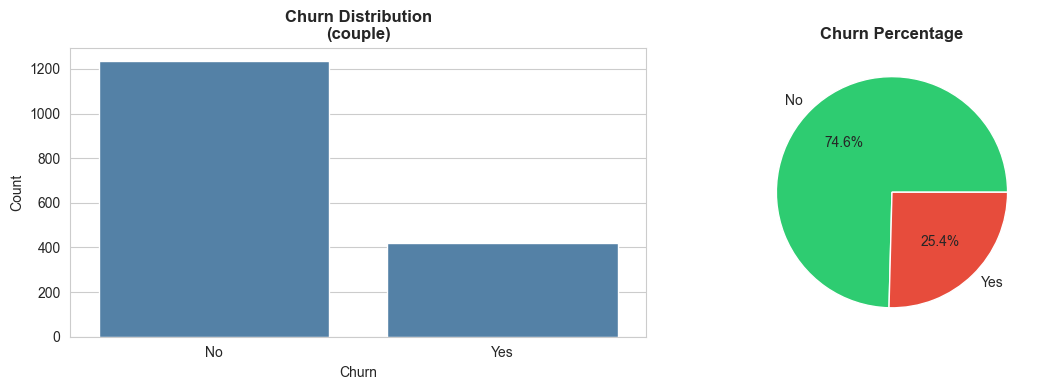


Total: 1653 customers
Churn: 420 (25.41%)
Not Churn: 1233 (74.59%)


In [6]:
couple_filtered = df[(df['Partner'] == 'Yes') & (df['Dependents'] == 'No')]

print(f'Total records: {len(couple_filtered)}')
print(couple_filtered['Churn'].value_counts())

print('\n Churn Percentage')
single_churn_pct = couple_filtered['Churn'].value_counts(normalize=True)*100
print(single_churn_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(data=couple_filtered, x='Churn', ax=axes[0], color='steelblue')
axes[0].set_title(f'Churn Distribution\n(couple)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart dengan percentage
churn_counts = couple_filtered['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal: {len(couple_filtered)} customers")
print(f"Churn: {(couple_filtered['Churn'] == 'Yes').sum()} ({(couple_filtered['Churn'] == 'Yes').sum()/len(couple_filtered)*100:.2f}%)")
print(f"Not Churn: {(couple_filtered['Churn'] == 'No').sum()} ({(couple_filtered['Churn'] == 'No').sum()/len(couple_filtered)*100:.2f}%)")

Total records: 361
Churn
No     284
Yes     77
Name: count, dtype: int64

 Churn Percentage
Churn
No     78.67036
Yes    21.32964
Name: proportion, dtype: float64


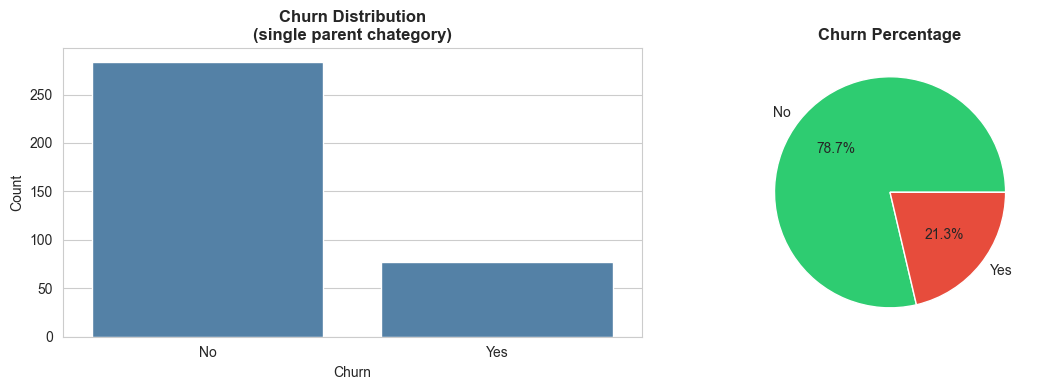


Total: 361 customers
Churn: 77 (21.33%)
Not Churn: 284 (78.67%)


In [8]:
single_parent_filtered = df[(df['Partner'] == 'No') & (df['Dependents'] == 'Yes')]

print(f'Total records: {len(single_parent_filtered)}')
print(single_parent_filtered['Churn'].value_counts())

print('\n Churn Percentage')
single_churn_pct = single_parent_filtered['Churn'].value_counts(normalize=True)*100
print(single_churn_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(data=single_parent_filtered, x='Churn', ax=axes[0], color='steelblue')
axes[0].set_title(f'Churn Distribution\n(single parent chategory)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart dengan percentage
churn_counts = single_parent_filtered['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal: {len(single_parent_filtered)} customers")
print(f"Churn: {(single_parent_filtered['Churn'] == 'Yes').sum()} ({(single_parent_filtered['Churn'] == 'Yes').sum()/len(single_parent_filtered)*100:.2f}%)")
print(f"Not Churn: {(single_parent_filtered['Churn'] == 'No').sum()} ({(single_parent_filtered['Churn'] == 'No').sum()/len(single_parent_filtered)*100:.2f}%)")

Total records: 1749
Churn
No     1500
Yes     249
Name: count, dtype: int64

 Churn Percentage
Churn
No     85.763293
Yes    14.236707
Name: proportion, dtype: float64


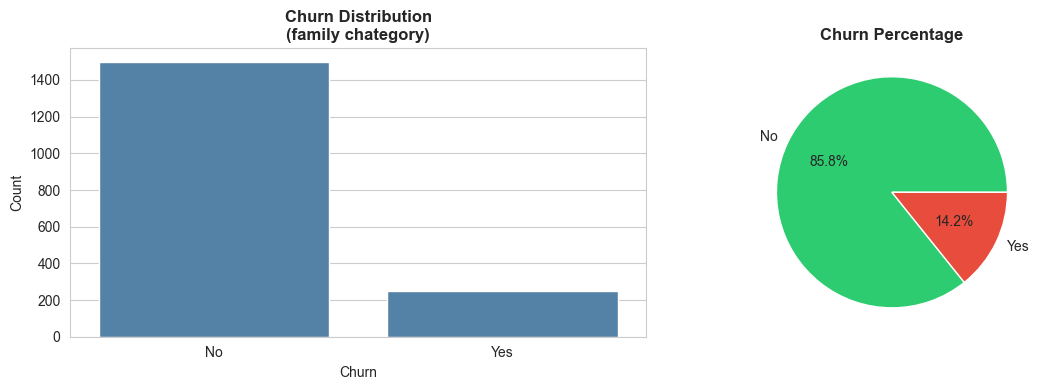


Total: 1749 customers
Churn: 249 (14.24%)
Not Churn: 1500 (85.76%)


In [9]:
family_filtered = df[(df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')]

print(f'Total records: {len(family_filtered)}')
print(family_filtered['Churn'].value_counts())

print('\n Churn Percentage')
single_churn_pct = family_filtered['Churn'].value_counts(normalize=True)*100
print(single_churn_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(data=family_filtered, x='Churn', ax=axes[0], color='steelblue')
axes[0].set_title(f'Churn Distribution\n(family chategory)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart dengan percentage
churn_counts = family_filtered['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal: {len(family_filtered)} customers")
print(f"Churn: {(family_filtered['Churn'] == 'Yes').sum()} ({(family_filtered['Churn'] == 'Yes').sum()/len(family_filtered)*100:.2f}%)")
print(f"Not Churn: {(family_filtered['Churn'] == 'No').sum()} ({(family_filtered['Churn'] == 'No').sum()/len(family_filtered)*100:.2f}%)")

## Total charges unbalance

In [10]:
print("Nilai TotalCharges yang tidak bisa dikonversi:")
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna() & df['TotalCharges'].notna()
problematic_values = df[mask]['TotalCharges'].unique()
print(problematic_values)
print(f"\nJumlah nilai problematic: {len(df[mask])}")

# Lihat sample record yang memiliki nilai problematic
print("\nSample records dengan TotalCharges problematic:")
print(df[mask][['customerID', 'TotalCharges']].head(15))

Nilai TotalCharges yang tidak bisa dikonversi:
<StringArray>
[' ']
Length: 1, dtype: str

Jumlah nilai problematic: 11

Sample records dengan TotalCharges problematic:
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE             


In [3]:
print(df['TotalCharges'].describe())
print(f"Non-null count: {df['TotalCharges'].notna().sum()}")

# Lihat berapa banyak NaN setelah konversi
print(f"NaN count: {df['TotalCharges'].isna().sum()}")

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object
Non-null count: 7043
NaN count: 0


## Internet Service exploration

In [19]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [13]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [14]:
df['TechSupport'].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [29]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [30]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [13]:
protection_filterd = df[(df['DeviceProtection'] == 'Yes') & (df['InternetService'] == 'DSL') | (df['InternetService'] == 'Fiber optic')]
print(f'{len(protection_filterd)}')

4161


In [16]:
support_filterd = df[(df['TechSupport'] == 'No') & (df['PhoneService'] == 'No') & (df['InternetService'] == 'DSL') | (df['InternetService'] == 'Fiber optic') ]
print(f'{len(support_filterd)}')

3489


In [18]:
security_filterd = df[(df['OnlineSecurity'] == 'Yes') & (df['InternetService'] == 'No') ]
print(f'{len(security_filterd)}')

0


In [17]:
backup_filtered = df[(df['OnlineBackup'] == 'Yes') & (df['InternetService'] == 'No') ]
print(f'{len(backup_filtered)}')

0


## Streaming & Movie Exploration

In [8]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [33]:
streaming_dsl_filterd = df[(df['StreamingMovies'] == 'No internet service') & (df['InternetService'] == 'DSL') ]
streaming_fiber_filterd = df[(df['StreamingMovies'] == 'No internet service') & (df['InternetService'] == 'Fiber optic')]
streaming_no_filtered =  df[(df['StreamingMovies'] == 'Yes') & (df['InternetService'] == 'No')]
print(f'{len(streaming_dsl_filterd)}')
print(f'{len(streaming_fiber_filterd)}')
print(f'{len(streaming_no_filtered)}')

0
0
0


In [10]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [32]:
tv_dsl_filterd = df[(df['StreamingTV'] == 'No internet service') & (df['InternetService'] == 'DSL') ]
tv_fiber_filterd = df[(df['StreamingTV'] == 'No internet service') & (df['InternetService'] == 'Fiber optic')]
tv_no_filtered =  df[(df['StreamingTV'] == 'No internet service') & (df['InternetService'] == 'No')]
print(f'{len(tv_dsl_filterd)}')
print(f'{len(tv_fiber_filterd)}')
print(f'{len(tv_no_filtered)}')

0
0
1526


## Cleaning & Transform Data

### Total charges clean

In [22]:
df['TotalCharges'] = df['TotalCharges'].str.strip()
df = df[df['TotalCharges'] != '']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

print(f"Data setelah drop whitespace TotalCharges: {len(df)} rows")

Data setelah drop whitespace TotalCharges: 7032 rows


### FamilyStatus Grouping

In [23]:
def assign_family_status(row):
    if row['Partner'] == 'No' and row['Dependents'] == 'No':
        return 'Single'
    elif row['Partner'] == 'Yes' and row['Dependents'] == 'No':
        return 'Couple'
    elif row['Partner'] == 'No' and row['Dependents'] == 'Yes':
        return 'Single Parent'
    else:
        return 'Family'

df['FamilyStatus'] = df.apply(assign_family_status, axis=1)

# Drop kolom Partner dan Dependents
df = df.drop(columns=['Partner', 'Dependents'])

print(f"FamilyStatus distribution:\n{df['FamilyStatus'].value_counts()}")

FamilyStatus distribution:
FamilyStatus
Single           3280
Family           1740
Couple           1653
Single Parent     359
Name: count, dtype: int64


### Internet service transfromation

In [24]:
internet_service_cols = ['DeviceProtection', 'TechSupport', 'OnlineSecurity', 
                         'OnlineBackup', 'StreamingTV', 'StreamingMovies']

for col in internet_service_cols:
    if col in df.columns:
        df[col] = df[col].replace('No internet service', 'No')

print(f"\nGabungan 'No internet service' menjadi 'No'")


Gabungan 'No internet service' menjadi 'No'


### MultipleLines Transformation

In [25]:
if 'MultipleLines' in df.columns:
    df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print(f"Gabungan 'No phone service' menjadi 'No'")


Gabungan 'No phone service' menjadi 'No'


In [26]:
print(f"\nData shape setelah cleaning: {df.shape}")
print(f"\nFinal check:")
print(f"TotalCharges NaN: {df['TotalCharges'].isna().sum()}")
print(f"FamilyStatus unique: {df['FamilyStatus'].unique()}")
print(f"DeviceProtection unique: {df['DeviceProtection'].unique()}")
print(f"MultipleLines unique: {df['MultipleLines'].unique()}")


Data shape setelah cleaning: (7032, 20)

Final check:
TotalCharges NaN: 0
FamilyStatus unique: <StringArray>
['Couple', 'Single', 'Single Parent', 'Family']
Length: 4, dtype: str
DeviceProtection unique: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines unique: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [27]:
df.head(10)

,customerID,gender,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyStatus
0,7590-VHVEG,Female,0,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Couple
1,5575-GNVDE,Male,0,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Single
2,3668-QPYBK,Male,0,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Single
3,7795-CFOCW,Male,0,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Single
4,9237-HQITU,Female,0,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Single
5,9305-CDSKC,Female,0,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,Single
6,1452-KIOVK,Male,0,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,Single Parent
7,6713-OKOMC,Female,0,10,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,Single
8,7892-POOKP,Female,0,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,Couple
9,6388-TABGU,Male,0,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,Single Parent


In [40]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [29]:
df.shape

(7032, 20)

## Save Eda To CSV

In [41]:
# 6. Save ke CSV
output_path = '../../Data/Telco_Customer_Churn_Cleaned.csv'
df.to_csv(output_path, index=False, sep=';')
print(f"\nData cleaned berhasil disave ke {output_path}")


Data cleaned berhasil disave ke ../../Data/Telco_Customer_Churn_Cleaned.csv
